# Misturas gaussianas e avaliação

**Tema:** Aprendizado Não Supervisionado › Clustering

Primeira metade: o algoritmo EM do zero para uma mistura de duas
gaussianas em 1D, conferido contra `GaussianMixture`, e depois o GMM em 2D
com os quatro tipos de covariância e a escolha de $K$ pelo BIC. Segunda
metade: o protocolo de avaliação do `teoria.pdf` — índices externos (ARI,
NMI) e estabilidade por bootstrap.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.mixture import GaussianMixture

rng = np.random.default_rng(53)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
CORES = np.array([AZUL, VERMELHO, VERDE, ROXO, AMBAR, "#5A5A5A"])
print("pronto")

pronto


## 1. O passo E do `teoria.pdf`, conferido

Componentes $\mathcal{N}(0,1)$ e $\mathcal{N}(4,1)$ com pesos iguais: a
responsabilidade da primeira componente pelo ponto 1,5 deveria ser ≈ 0,88.

In [2]:
for x in [1.5, 2.0, 3.0]:
    d1, d2 = norm.pdf(x, 0, 1), norm.pdf(x, 4, 1)
    print(f"x={x}: densidades ({d1:.4f}, {d2:.4f}) -> gamma_1 = {d1 / (d1 + d2):.3f}")

x=1.5: densidades (0.1295, 0.0175) -> gamma_1 = 0.881
x=2.0: densidades (0.0540, 0.0540) -> gamma_1 = 0.500
x=3.0: densidades (0.0044, 0.2420) -> gamma_1 = 0.018


## 2. EM do zero para duas gaussianas em 1D

Dados gerados por uma mistura conhecida: 60% de $\mathcal{N}(2, 0{,}8^2)$ e
40% de $\mathcal{N}(6, 1{,}5^2)$. O EM deve recuperar esses parâmetros sem
saber de onde veio cada ponto.

EM do zero (84 iterações): mu=[2.005 5.871], sigma=[0.82  1.478], pi=[0.608 0.392]
sklearn                : mu=[2.046 5.998], sigma=[0.851 1.39 ], pi=[0.627 0.373]
verdade                : mu=[2, 6], sigma=[0.8, 1.5], pi=[0.6, 0.4]
a log-verossimilhança nunca caiu? True


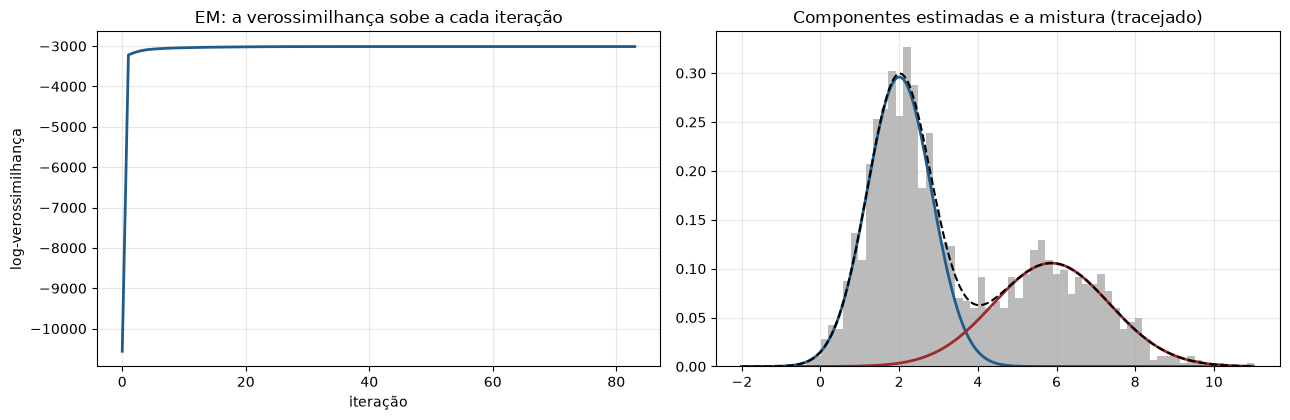

In [3]:
n = 1500
origem = rng.random(n) < 0.6
x = np.where(origem, rng.normal(2, 0.8, n), rng.normal(6, 1.5, n))

def em_duas_gaussianas(x, mu, sigma, pi, n_iter=200, tol=1e-8):
    mu, sigma, pi = np.array(mu, float), np.array(sigma, float), np.array(pi, float)
    historico = []
    for _ in range(n_iter):
        # passo E: responsabilidades
        dens = pi * norm.pdf(x[:, None], mu, sigma)          # (n, 2)
        loglik = np.log(dens.sum(axis=1)).sum()
        gamma = dens / dens.sum(axis=1, keepdims=True)
        # passo M: médias ponderadas pelas responsabilidades
        Nk = gamma.sum(axis=0)
        mu = (gamma * x[:, None]).sum(axis=0) / Nk
        sigma = np.sqrt((gamma * (x[:, None] - mu) ** 2).sum(axis=0) / Nk)
        pi = Nk / len(x)
        historico.append(loglik)
        if len(historico) > 1 and abs(historico[-1] - historico[-2]) < tol:
            break
    return mu, sigma, pi, np.array(historico)

mu, sigma, pi, hist = em_duas_gaussianas(x, mu=[0, 1], sigma=[1, 1], pi=[0.5, 0.5])
print(f"EM do zero ({len(hist)} iterações): mu={mu.round(3)}, sigma={sigma.round(3)}, pi={pi.round(3)}")
gm = GaussianMixture(2, random_state=0).fit(x.reshape(-1, 1))
ordem = np.argsort(gm.means_.ravel())
print(f"sklearn                : mu={gm.means_.ravel()[ordem].round(3)}, "
      f"sigma={np.sqrt(gm.covariances_.ravel()[ordem]).round(3)}, pi={gm.weights_[ordem].round(3)}")
print("verdade                : mu=[2, 6], sigma=[0.8, 1.5], pi=[0.6, 0.4]")
print("a log-verossimilhança nunca caiu?", bool(np.all(np.diff(hist) > -1e-9)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.3))
ax1.plot(hist, color=AZUL, lw=2)
ax1.set_xlabel("iteração"); ax1.set_ylabel("log-verossimilhança")
ax1.set_title("EM: a verossimilhança sobe a cada iteração")
grade = np.linspace(-2, 11, 400)
ax2.hist(x, bins=60, density=True, color="#BBBBBB")
for k, cor in zip(range(2), [AZUL, VERMELHO]):
    ax2.plot(grade, pi[k] * norm.pdf(grade, mu[k], sigma[k]), color=cor, lw=2)
ax2.plot(grade, (pi * norm.pdf(grade[:, None], mu, sigma)).sum(axis=1), "k--", lw=1.5)
ax2.set_title("Componentes estimadas e a mistura (tracejado)")
plt.tight_layout(); plt.show()

## 3. Tipos de covariância e escolha de K pelo BIC

Dados 2D com 3 componentes alongadas e de orientações diferentes.

covariância    diag    full  spherical    tied
K                                             
1            7538.0  7543.0     7542.0  7543.0
2            7106.0  6837.0     7288.0  7256.0
3            6639.0  6131.0     6829.0  6815.0
4            6500.0  6166.0     6687.0  6696.0
5            6366.0  6199.0     6560.0  6532.0
6            6391.0  6238.0     6455.0  6429.0
7            6365.0  6272.0     6386.0  6377.0

menor BIC: covariância='full', K=3


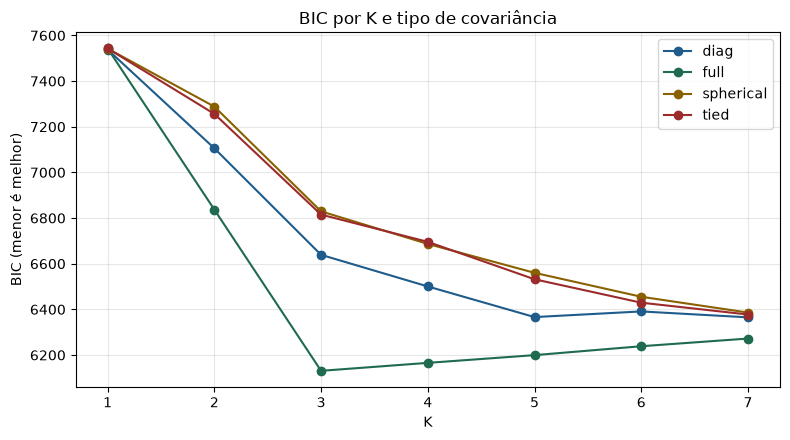

In [4]:
partes = [rng.multivariate_normal([0, 0], [[2.0, 1.5], [1.5, 1.6]], 300),
          rng.multivariate_normal([5, 0], [[0.3, 0.0], [0.0, 2.0]], 250),
          rng.multivariate_normal([2, 5], [[1.8, -1.2], [-1.2, 1.2]], 250)]
X = np.vstack(partes)
y_verdade = np.repeat([0, 1, 2], [300, 250, 250])

linhas = []
for tipo in ["spherical", "diag", "tied", "full"]:
    for K in range(1, 8):
        g = GaussianMixture(K, covariance_type=tipo, n_init=3, random_state=0).fit(X)
        linhas.append({"covariância": tipo, "K": K, "BIC": g.bic(X)})
bic = pd.DataFrame(linhas).pivot(index="K", columns="covariância", values="BIC")
print(bic.round(0).to_string())
tipo_min, K_min = bic.stack().idxmin()[::-1]
print(f"\nmenor BIC: covariância='{tipo_min}', K={K_min}")

fig, ax = plt.subplots(figsize=(8, 4.5))
for tipo, cor in zip(bic.columns, [AZUL, VERDE, AMBAR, VERMELHO]):
    ax.plot(bic.index, bic[tipo], "o-", color=cor, label=tipo)
ax.set_xlabel("K"); ax.set_ylabel("BIC (menor é melhor)"); ax.legend()
ax.set_title("BIC por K e tipo de covariância")
plt.tight_layout(); plt.show()

**Leitura esperada:** com covariância `spherical` o BIC continua caindo
além de K=3 — para imitar elipses alongadas com círculos, o modelo precisa
de mais componentes. Com `full`, o mínimo aparece em K=3: a forma certa
dispensa componentes extras.

## 4. Pertinência suave: quem o modelo não sabe classificar

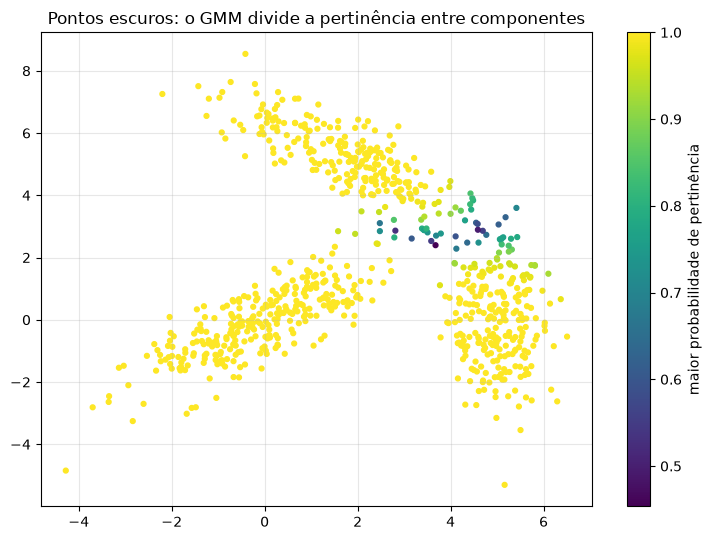

pontos com certeza < 0.8: 4.1%


In [5]:
gmm = GaussianMixture(3, covariance_type="full", n_init=3, random_state=0).fit(X)
P = gmm.predict_proba(X)
certeza = P.max(axis=1)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sc = ax.scatter(X[:, 0], X[:, 1], c=certeza, cmap="viridis", s=12)
fig.colorbar(sc, label="maior probabilidade de pertinência")
ax.set_title("Pontos escuros: o GMM divide a pertinência entre componentes")
plt.tight_layout(); plt.show()
print(f"pontos com certeza < 0.8: {np.mean(certeza < 0.8):.1%}")

## 5. Índices externos: ARI e NMI

Quando existe um rótulo de referência (aqui, sabemos a verdade porque
geramos os dados), ARI e NMI medem a concordância sem se importar com os
nomes dos grupos.

In [6]:
permutado = (y_verdade + 1) % 3  # mesmos grupos, nomes trocados
print(f"ARI da verdade contra ela mesma com nomes trocados: "
      f"{adjusted_rand_score(y_verdade, permutado):.3f}")
aleatorio = rng.integers(0, 3, len(y_verdade))
print(f"ARI de uma partição aleatória: {adjusted_rand_score(y_verdade, aleatorio):.3f}")

modelos = {"k-means": KMeans(3, n_init=10, random_state=0).fit_predict(X),
           "GMM spherical": GaussianMixture(3, covariance_type="spherical",
                                            random_state=0).fit(X).predict(X),
           "GMM full": gmm.predict(X),
           "DBSCAN": DBSCAN(eps=0.45, min_samples=10).fit_predict(X)}
for nome, rot in modelos.items():
    print(f"{nome:>14s}: ARI={adjusted_rand_score(y_verdade, rot):.3f}  "
          f"NMI={normalized_mutual_info_score(y_verdade, rot):.3f}")

ARI da verdade contra ela mesma com nomes trocados: 1.000
ARI de uma partição aleatória: -0.001
       k-means: ARI=0.902  NMI=0.864
 GMM spherical: ARI=0.890  NMI=0.850
      GMM full: ARI=0.953  NMI=0.922
        DBSCAN: ARI=0.786  NMI=0.745


## 6. Estabilidade por bootstrap

Para cada $k$, reamostramos a base 30 vezes, reagrupamos e comparamos a
partição da reamostra com a partição da base original **nos mesmos
pontos**. Grupos reais sobrevivem à perturbação; grupos-artefato não.

In [7]:
def estabilidade(X, k, n_boot=30):
    base = KMeans(k, n_init=10, random_state=0).fit(X)
    aris = []
    for b in range(n_boot):
        idx = np.random.default_rng(b).choice(len(X), len(X), replace=True)
        rot_b = KMeans(k, n_init=10, random_state=b).fit(X[idx]).predict(X)
        aris.append(adjusted_rand_score(base.labels_, rot_b))
    return np.mean(aris), np.std(aris)

Xb, _ = make_blobs(n_samples=600, centers=[[-4, -3], [0, 4], [4, -3], [5, 3]],
                   cluster_std=1.3, random_state=11)
print(f"{'k':>3s} {'ARI médio':>10s} {'desvio':>8s}")
for k in range(2, 8):
    m, s = estabilidade(Xb, k)
    print(f"{k:>3d} {m:>10.3f} {s:>8.3f}")

  k  ARI médio   desvio


  2      0.778    0.302


  3      0.996    0.005


  4      0.993    0.007


  5      0.821    0.071


  6      0.786    0.084


  7      0.688    0.080


**Leitura esperada:** $k=3$ e $k=4$ são muito estáveis (ARI perto de 1);
a partir de $k=5$ a estabilidade cai e o desvio sobe. A razão: **fundir**
dois grupos naturais vizinhos (o que $k=3$ faz) é uma decisão estável —
toda reamostra funde os mesmos dois; **cortar** um grupo natural ao meio
(o que $k \geq 5$ exige) não é — cada reamostra corta num lugar diferente.
Estabilidade descarta bem os $k$ grandes demais, mas sozinha não
distingue $k=3$ de $k=4$: por isso ela é combinada com os índices
internos, que aqui apontam para 4. E $k=2$ é instável porque há mais de
uma forma quase igualmente boa de juntar quatro grupos em dois.

## O que levar deste notebook

- EM alterna responsabilidades (passo E) e médias ponderadas (passo M); a
  verossimilhança sobe a cada iteração.
- O tipo de covariância é uma escolha de forma: com a forma certa, o BIC
  escolhe menos componentes.
- A pertinência suave identifica os pontos ambíguos — informação que o
  k-means descarta.
- ARI e NMI comparam partições ignorando nomes; ARI é ajustado pelo acaso.
- Estabilidade por bootstrap é o teste de realidade mais geral de um
  agrupamento.

→ Próximo: **Caso real: segmentação de clientes**, o protocolo completo
aplicado de ponta a ponta.